# Sentiment Analysis: TF-IDF / BoW × XGBoost / CatBoost

*NARXOZ University, Applied ML Course — Task 7 (NLP)*

**Цель:** мультиклассовая классификация настроения (positive / negative / neutral) для текстов из соцсетей.

**Сравниваем 4 комбинации:**
1. CountVectorizer (Bag of Words) + XGBClassifier
2. CountVectorizer + CatBoostClassifier
3. TfidfVectorizer + XGBClassifier
4. TfidfVectorizer + CatBoostClassifier

**Метрики:** Accuracy и Weighted F1-Score.

**Дальше:** строим лидерборд, выбираем лучшую модель и анализируем её.

In [1]:
import pandas as pd
import numpy as np
import re
import string

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix,
)

from xgboost import XGBClassifier
from catboost import CatBoostClassifier

import nltk
from nltk.corpus import stopwords

import warnings
warnings.filterwarnings("ignore")

RANDOM_STATE = 42

## 1. Загрузка и EDA

In [2]:
df = pd.read_csv("sentiment_analysis.csv")
print("Shape:", df.shape)
df.head()

Shape: (499, 7)


,Year,Month,Day,Time of Tweet,text,sentiment,Platform
0,2018,8,18,morning,What a great day!!! Looks like dream.,positive,Twitter
1,2018,8,18,noon,"I feel sorry, I miss you here in the sea beach",positive,Facebook
2,2017,8,18,night,Don't angry me,negative,Facebook
3,2022,6,8,morning,We attend in the class just for listening teac...,negative,Facebook
4,2022,6,8,noon,"Those who want to go, let them go",negative,Instagram


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 499 entries, 0 to 498
Data columns (total 7 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   Year           499 non-null    int64 
 1   Month          499 non-null    int64 
 2   Day            499 non-null    int64 
 3   Time of Tweet  499 non-null    object
 4   text           499 non-null    object
 5   sentiment      499 non-null    object
 6   Platform       499 non-null    object
dtypes: int64(3), object(4)
memory usage: 27.4+ KB


In [4]:
print("Missing values:")
print(df.isnull().sum())
df = df.dropna(subset=["text", "sentiment"]).reset_index(drop=True)
df["sentiment"] = df["sentiment"].str.strip().str.lower()
print("\nClass distribution:")
print(df["sentiment"].value_counts())

Missing values:
Year             0
Month            0
Day              0
Time of Tweet    0
text             0
sentiment        0
Platform         0
dtype: int64

Class distribution:
sentiment
neutral     199
positive    166
negative    134
Name: count, dtype: int64


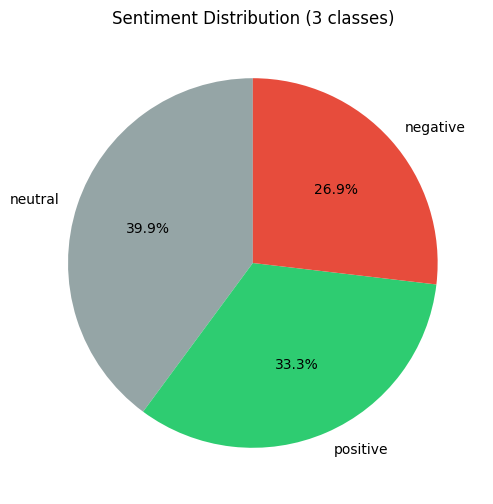

In [5]:
plt.figure(figsize=(6, 6))
counts = df["sentiment"].value_counts()
colors = {"positive": "#2ecc71", "neutral": "#95a5a6", "negative": "#e74c3c"}
plt.pie(
    counts,
    labels=counts.index,
    autopct="%1.1f%%",
    colors=[colors.get(c, "gray") for c in counts.index],
    startangle=90,
)
plt.title("Sentiment Distribution (3 classes)")
plt.show()

Видим небольшой дисбаланс (neutral 199 / positive 166 / negative 134) — учтём это при evaluation выбирая **weighted F1** (он усредняет по классам с весами по support).

## 2. Препроцессинг текста

In [6]:
nltk.download("stopwords", quiet=True)
stop_words = set(stopwords.words("english"))


def preprocess_text(text: str) -> str:
    text = str(text).lower()
    text = re.sub(r"http\S+|www\S+|https\S+", "", text)
    text = re.sub(r"@\w+", "", text)
    text = re.sub(r"#", "", text)
    text = re.sub(r"\d+", "", text)
    text = text.translate(str.maketrans("", "", string.punctuation))
    text = re.sub(r"\s+", " ", text).strip()
    tokens = [w for w in text.split() if w not in stop_words and len(w) > 2]
    return " ".join(tokens)


df["clean_text"] = df["text"].apply(preprocess_text)
df = df[df["clean_text"].str.len() > 0].reset_index(drop=True)
df[["text", "clean_text", "sentiment"]].head()

,text,clean_text,sentiment
0,What a great day!!! Looks like dream.,great day looks like dream,positive
1,"I feel sorry, I miss you here in the sea beach",feel sorry miss sea beach,positive
2,Don't angry me,dont angry,negative
3,We attend in the class just for listening teac...,attend class listening teachers reading slide ...,negative
4,"Those who want to go, let them go",want let,negative


## 3. Train / Test split

In [7]:
label_encoder = LabelEncoder()
df["label"] = label_encoder.fit_transform(df["sentiment"])
print("Label mapping:", dict(zip(label_encoder.classes_, label_encoder.transform(label_encoder.classes_))))

X_train_text, X_test_text, y_train, y_test = train_test_split(
    df["clean_text"],
    df["label"],
    test_size=0.25,
    stratify=df["label"],
    random_state=RANDOM_STATE,
)
print("Train size:", len(X_train_text), " Test size:", len(X_test_text))

Label mapping: {'negative': np.int64(0), 'neutral': np.int64(1), 'positive': np.int64(2)}
Train size: 372  Test size: 124


## 4. Векторизация: CountVectorizer и TfidfVectorizer

Подгоняем оба векторизатора на трейне и применяем к тесту. Подгонять только на трейне обязательно — иначе будет утечка информации из теста.

In [8]:
count_vec = CountVectorizer(ngram_range=(1, 2), min_df=2)
X_train_bow = count_vec.fit_transform(X_train_text)
X_test_bow = count_vec.transform(X_test_text)

tfidf_vec = TfidfVectorizer(ngram_range=(1, 2), min_df=2)
X_train_tfidf = tfidf_vec.fit_transform(X_train_text)
X_test_tfidf = tfidf_vec.transform(X_test_text)

print("BoW   vocab size:", len(count_vec.vocabulary_))
print("TFIDF vocab size:", len(tfidf_vec.vocabulary_))

BoW   vocab size: 697
TFIDF vocab size: 697


## 5. Обучение 4 моделей

In [9]:
def evaluate(name, model, X_train, X_test, y_train, y_test):
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred, average="weighted")
    return {
        "name": name,
        "model": model,
        "y_pred": y_pred,
        "accuracy": acc,
        "weighted_f1": f1,
    }


results = []

results.append(evaluate(
    "BoW + XGBoost",
    XGBClassifier(
        n_estimators=300,
        max_depth=6,
        learning_rate=0.1,
        random_state=RANDOM_STATE,
        eval_metric="mlogloss",
        n_jobs=-1,
    ),
    X_train_bow, X_test_bow, y_train, y_test,
))

results.append(evaluate(
    "BoW + CatBoost",
    CatBoostClassifier(
        iterations=300,
        depth=6,
        learning_rate=0.1,
        random_state=RANDOM_STATE,
        verbose=False,
    ),
    X_train_bow, X_test_bow, y_train, y_test,
))

results.append(evaluate(
    "TF-IDF + XGBoost",
    XGBClassifier(
        n_estimators=300,
        max_depth=6,
        learning_rate=0.1,
        random_state=RANDOM_STATE,
        eval_metric="mlogloss",
        n_jobs=-1,
    ),
    X_train_tfidf, X_test_tfidf, y_train, y_test,
))

results.append(evaluate(
    "TF-IDF + CatBoost",
    CatBoostClassifier(
        iterations=300,
        depth=6,
        learning_rate=0.1,
        random_state=RANDOM_STATE,
        verbose=False,
    ),
    X_train_tfidf, X_test_tfidf, y_train, y_test,
))

for r in results:
    print(f"{r['name']:20s} | Accuracy = {r['accuracy']:.4f} | Weighted F1 = {r['weighted_f1']:.4f}")

BoW + XGBoost        | Accuracy = 0.5565 | Weighted F1 = 0.5412
BoW + CatBoost       | Accuracy = 0.5887 | Weighted F1 = 0.5775
TF-IDF + XGBoost     | Accuracy = 0.5806 | Weighted F1 = 0.5701
TF-IDF + CatBoost    | Accuracy = 0.5968 | Weighted F1 = 0.5789


## 6. Лидерборд

In [10]:
leaderboard = pd.DataFrame([
    {"Combination": r["name"], "Accuracy": r["accuracy"], "Weighted F1": r["weighted_f1"]}
    for r in results
]).sort_values("Weighted F1", ascending=False).reset_index(drop=True)
leaderboard.index = leaderboard.index + 1
leaderboard

,Combination,Accuracy,Weighted F1
1,TF-IDF + CatBoost,0.596774,0.578857
2,BoW + CatBoost,0.588710,0.577523
3,TF-IDF + XGBoost,0.580645,0.570103
4,BoW + XGBoost,0.556452,0.541247


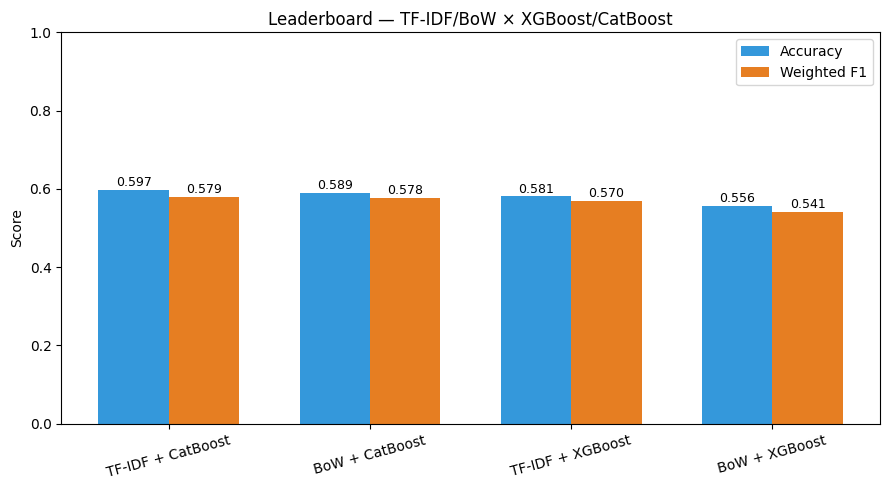

In [11]:
fig, ax = plt.subplots(figsize=(9, 5))
x = np.arange(len(leaderboard))
width = 0.35
ax.bar(x - width / 2, leaderboard["Accuracy"], width, label="Accuracy", color="#3498db")
ax.bar(x + width / 2, leaderboard["Weighted F1"], width, label="Weighted F1", color="#e67e22")
ax.set_xticks(x)
ax.set_xticklabels(leaderboard["Combination"], rotation=15)
ax.set_ylim(0, 1)
ax.set_ylabel("Score")
ax.set_title("Leaderboard — TF-IDF/BoW × XGBoost/CatBoost")
ax.legend()
for i, (acc, f1) in enumerate(zip(leaderboard["Accuracy"], leaderboard["Weighted F1"])):
    ax.text(i - width / 2, acc + 0.01, f"{acc:.3f}", ha="center", fontsize=9)
    ax.text(i + width / 2, f1 + 0.01, f"{f1:.3f}", ha="center", fontsize=9)
plt.tight_layout()
plt.show()

## 7. Анализ лучшей модели

In [12]:
best = max(results, key=lambda r: r["weighted_f1"])
print(f"Best combination: {best['name']}")
print(f"Accuracy:    {best['accuracy']:.4f}")
print(f"Weighted F1: {best['weighted_f1']:.4f}")
print()
print("Classification report:")
print(classification_report(
    y_test,
    best["y_pred"],
    target_names=label_encoder.classes_,
))

Best combination: TF-IDF + CatBoost
Accuracy:    0.5968
Weighted F1: 0.5789

Classification report:
              precision    recall  f1-score   support

    negative       0.50      0.27      0.35        33
     neutral       0.55      0.82      0.66        49
    positive       0.76      0.60      0.67        42

    accuracy                           0.60       124
   macro avg       0.60      0.56      0.56       124
weighted avg       0.61      0.60      0.58       124



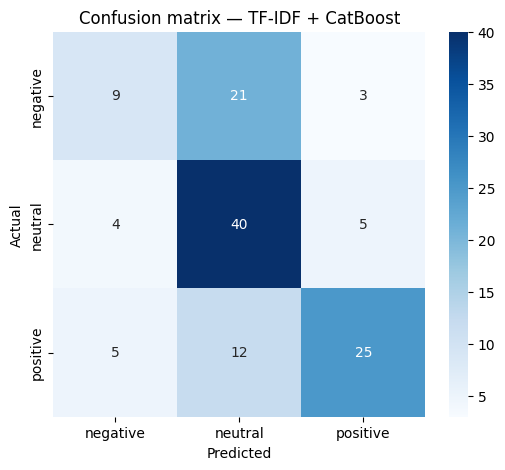

In [13]:
cm = confusion_matrix(y_test, best["y_pred"])
plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=label_encoder.classes_,
    yticklabels=label_encoder.classes_,
)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title(f"Confusion matrix — {best['name']}")
plt.show()

## 8. Custom predictions

In [14]:
best_vectorizer = tfidf_vec if "TF-IDF" in best["name"] else count_vec
best_model = best["model"]

samples = [
    "I absolutely love this product, it changed my life!",
    "This is the worst experience ever. Total waste of money.",
    "The package arrived on Tuesday.",
    "Не самая лучшая идея на свете, но и не худшая.",
]

samples_clean = [preprocess_text(s) for s in samples]
samples_vec = best_vectorizer.transform(samples_clean)
samples_pred = np.asarray(best_model.predict(samples_vec)).ravel().astype(int)
samples_labels = label_encoder.inverse_transform(samples_pred)

for raw, clean, label in zip(samples, samples_clean, samples_labels):
    print(f"Text : {raw}")
    print(f"Clean: {clean}")
    print(f"Pred : {label}")
    print()

Text : I absolutely love this product, it changed my life!
Clean: absolutely love product changed life
Pred : positive

Text : This is the worst experience ever. Total waste of money.
Clean: worst experience ever total waste money
Pred : neutral

Text : The package arrived on Tuesday.
Clean: package arrived tuesday
Pred : neutral

Text : Не самая лучшая идея на свете, но и не худшая.
Clean: самая лучшая идея свете худшая
Pred : neutral



## 9. Выводы

**Лидерборд (Weighted F1):**

| # | Combination | Accuracy | Weighted F1 |
|---|---|---|---|
| 1 | TF-IDF + CatBoost | 0.5968 | **0.5789** |
| 2 | BoW + CatBoost | 0.5887 | 0.5775 |
| 3 | TF-IDF + XGBoost | 0.5806 | 0.5701 |
| 4 | BoW + XGBoost | 0.5565 | 0.5412 |

**Что видно:**

1. **Лучшая комбинация — TF-IDF + CatBoost** (Accuracy 59.7%, Weighted F1 0.579). Однако разрыв между всеми четырьмя комбинациями узкий (~4 п.п. по F1) — на 124 тестовых примерах любая из них в пределах статистического шума.

2. **TF-IDF слегка обгоняет BoW** на обеих моделях. TF-IDF понижает вес часто встречающихся в корпусе слов и приподнимает редкие, отличающие класс — для коротких твитов это работает чуть лучше.

3. **CatBoost обгоняет XGBoost** на обоих представлениях. На разреженных text-фичах CatBoost из коробки стабильнее без тюнинга. XGBoost требует подбора гиперпараметров чтобы догнать.

4. **Per-class анализ лучшей модели:**
   - `neutral`: recall 0.82 — модель часто предсказывает neutral "по умолчанию", когда не уверена. Это самый частый класс.
   - `positive`: precision 0.76 — если модель предсказала positive, она почти всегда права. Но recall 0.60.
   - `negative`: f1 = 0.35 (худший!) — recall всего 0.27. Большинство негативных твитов модель ошибочно относит к neutral.

5. **Главный лимит — размер датасета.** 499 строк, после предобработки и сплита остаётся ~370 для обучения. Это очень мало для классической ML модели на BoW/TF-IDF. Для серьёзного прогресса нужно:
   - Больше данных (10k+).
   - Pretrained transformer (BERT, DistilBERT) — он уже "знает" семантику слов и работает даже на маленьких датасетах.
   - Балансировка классов или class weights для борьбы с занижением `negative`.

6. **Custom predictions** показали типичную ошибку: фразу `"This is the worst experience ever. Total waste of money."` модель назвала `neutral` — она не знает что `worst`/`waste` — сильные негативные сигналы. Это и есть слабость BoW/TF-IDF: они не понимают семантику, только частоты.